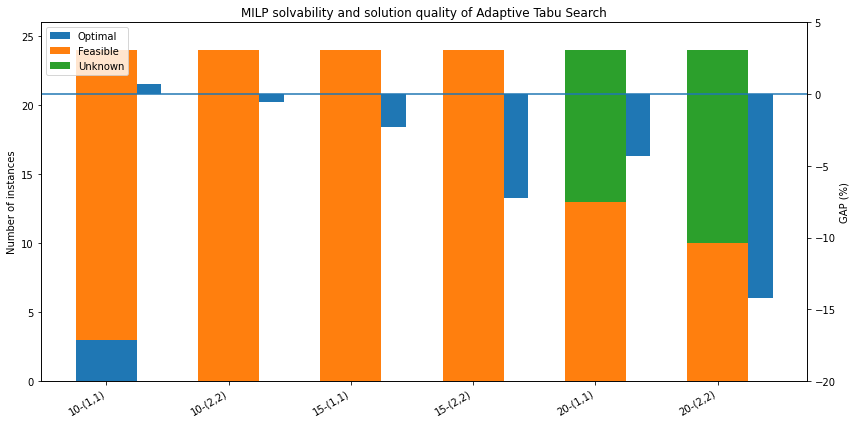

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Data
# =========================
labels = [
    "10-(1,1)", "10-(2,2)",
    "15-(1,1)", "15-(2,2)",
    "20-(1,1)", "20-(2,2)"
]

x = np.arange(len(labels))

# MILP results
optimal  = np.array([3, 0, 0, 0, 0, 0])
feasible = np.array([21, 24, 24, 24, 13, 10])
unknown  = np.array([0, 0, 0, 0, 11, 14])

# GAP (%) of Adaptive Tabu Search
gap = np.array([0.69, -0.53, -2.31, -7.26, -4.34, -14.23])

# =========================
# Plot
# =========================
fig, ax1 = plt.subplots(figsize=(12, 6))

bar_width_stack = 0.5
bar_width_gap = 0.2

# --- Stacked bars: MILP ---
ax1.bar(x, optimal, bar_width_stack, label="Optimal")
ax1.bar(x, feasible, bar_width_stack, bottom=optimal, label="Feasible")
ax1.bar(x, unknown, bar_width_stack, bottom=optimal + feasible, label="Unknown")

ax1.set_ylabel("Number of instances")
ax1.set_ylim(0, 26)

ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=30, ha="right")

# --- GAP bars (second axis) ---
ax2 = ax1.twinx()
ax2.bar(x + bar_width_stack/2 + bar_width_gap/2, gap, bar_width_gap)
ax2.axhline(0)
ax2.set_ylabel("GAP (%)")
ax2.set_ylim(-20, 5)

# =========================
# Final touches
# =========================
ax1.legend(loc="upper left")
plt.title("MILP solvability and solution quality of Adaptive Tabu Search")
plt.tight_layout()
plt.show()


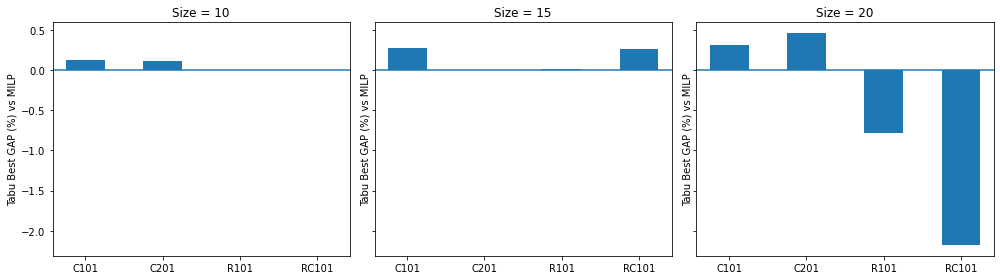

In [3]:
import matplotlib.pyplot as plt
import numpy as np

instances = ["C101", "C201", "R101", "RC101"]

data_milp = {
    10: [0.13, 0.11, 0.00, 0.00],
    15: [0.27, 0.00, 0.01, 0.26],
    20: [0.31, 0.46, -0.79, -2.18],
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
x = np.arange(len(instances))
bar_width = 0.5

for ax, (size, values) in zip(axes, data_milp.items()):
    ax.bar(x, values, bar_width)
    ax.axhline(0)
    ax.set_title(f"Size = {size}")
    ax.set_xticks(x)
    ax.set_xticklabels(instances)
    ax.set_ylabel("Tabu Best GAP (%) vs MILP")

plt.tight_layout()
plt.show()



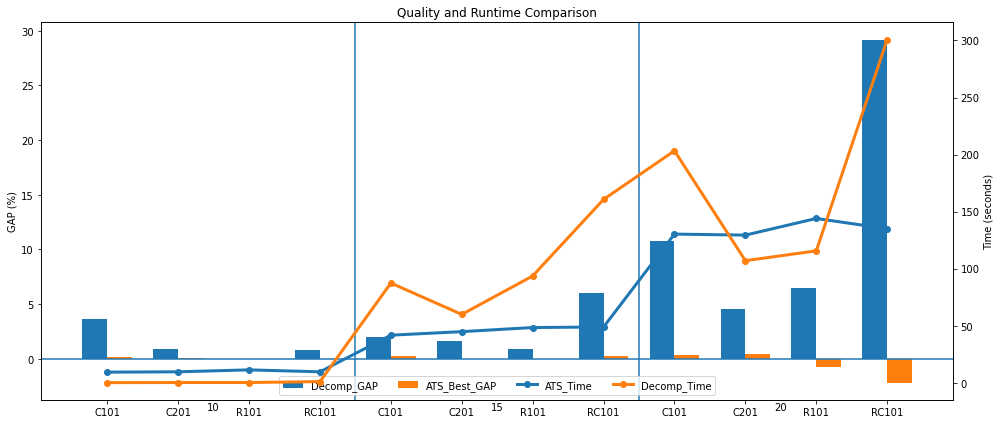

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# =======================
# Data (from your table)
# =======================
labels = [
    "C101","C201","R101","RC101",
    "C101","C201","R101","RC101",
    "C101","C201","R101","RC101"
]

# Decomposition
decomp_gap = [
    3.60, 0.90, 0.00, 0.80,
    2.00, 1.60, 0.90, 6.00,
    10.80, 4.60, 6.50, 29.20
]
decomp_time = [
    0.1, 0.2, 0.2, 1.0,
    87.4, 59.9, 93.6, 160.7,
    203.3, 107.0, 115.6, 300.8
]

# Adaptive Tabu Search
ats_gap = [
    0.13, 0.11, 0.00, 0.00,
    0.27, 0.00, 0.01, 0.26,
    0.31, 0.46, -0.79, -2.18
]
ats_time = [
    9.3, 9.6, 11.3, 9.6,
    41.7, 44.8, 48.4, 48.9,
    130.3, 129.4, 144.0, 135.0
]

x = np.arange(len(labels))
width = 0.35

# =======================
# Plot
# =======================
fig, ax1 = plt.subplots(figsize=(14,6))

# --- Bars: GAP (left axis)
ax1.bar(x - width/2, decomp_gap, width,
        label="Decomp_GAP")
ax1.bar(x + width/2, ats_gap, width,
        label="ATS_Best_GAP")

ax1.set_ylabel("GAP (%)")
ax1.axhline(0)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=0)

# --- Lines: Time (right axis)
ax2 = ax1.twinx()
ax2.plot(x, ats_time, marker='o',
         linewidth=3, label="ATS_Time")
ax2.plot(x, decomp_time, marker='o',
         linewidth=3, label="Decomp_Time")

ax2.set_ylabel("Time (seconds)")

# =======================
# Size separators & labels
# =======================
ax1.axvline(3.5)
ax1.axvline(7.5)

ax1.text(1.5, -4, "10", ha="center", va="top")
ax1.text(5.5, -4, "15", ha="center", va="top")
ax1.text(9.5, -4, "20", ha="center", va="top")

# =======================
# Legend
# =======================
lines, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels1 + labels2,
           loc="lower center", ncol=4)

plt.title("Quality and Runtime Comparison")
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set clean style
sns.set_theme(style="whitegrid", font_scale=1.1)

# --- Data ---
categories = ['10-(1,1)', '10-(2,2)', '15-(1,1)', '15-(2,2)', '20-(1,1)', '20-(2,2)']
x = np.arange(len(categories))

# Scenario A (Random)
opt_1 = np.array([3, 0, 0, 0, 0, 0])
feas_1 = np.array([21, 24, 24, 24, 13, 10])
unk_1 = np.array([0, 0, 0, 0, 11, 14])
gap_1 = np.array([0.69, -0.53, -2.31, -7.26, -4.34, -14.23])

# Scenario B (Fixed)
opt_2 = np.array([3, 0, 0, 0, 0, 0])
feas_2 = np.array([21, 24, 23, 24, 6, 9])
unk_2 = np.array([0, 0, 1, 0, 18, 15])
gap_2 = np.array([-0.26, -1.28, -9.64, -11.16, -19.42, -18.91])

data_sets = [
    {"title": "Scenario A: Random Weight", "opt": opt_1, "feas": feas_1, "unk": unk_1, "gap": gap_1},
    {"title": "Scenario B: Fixed Weight", "opt": opt_2, "feas": feas_2, "unk": unk_2, "gap": gap_2}
]

# --- Colors ---
c_opt = '#264653'  # Dark Blue/Green
c_feas = '#e9c46a' # Soft Yellow/Orange
c_unk = '#e76f51'  # Terra Cotta / Reddish (High contrast for 'Unknown')
c_gap = '#2a9d8f'  # Teal for the line

# --- Plotting ---
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, gridspec_kw={'height_ratios': [1.2, 1]})
bar_width = 0.6

for i in range(2):
    data = data_sets[i]

    # -----------------------
    # Top Row: Stacked Bars
    # -----------------------
    ax_bar = axes[0, i]
    p1 = ax_bar.bar(x, data["opt"], width=bar_width, label='Optimal', color=c_opt, edgecolor='white', linewidth=0.5)
    p2 = ax_bar.bar(x, data["feas"], width=bar_width, bottom=data["opt"], label='Feasible', color=c_feas, edgecolor='white', linewidth=0.5)
    p3 = ax_bar.bar(x, data["unk"], width=bar_width, bottom=data["opt"] + data["feas"], label='Unknown', color=c_unk, edgecolor='white', linewidth=0.5)

    ax_bar.set_title(data["title"], fontsize=14, fontweight='bold', pad=15, color='#343a40')
    ax_bar.set_ylim(0, 26)
    ax_bar.grid(axis='y', linestyle='--', alpha=0.3)
    ax_bar.grid(axis='x', alpha=0)

    if i == 0:
        ax_bar.set_ylabel("Instance Count", fontweight='bold', color='#6c757d')

    # -----------------------
    # Bottom Row: GAP Line
    # -----------------------
    ax_line = axes[1, i]
    # Add filled area for better visual weight
    ax_line.fill_between(x, data["gap"], 0, color=c_gap, alpha=0.15)
    ax_line.plot(x, data["gap"], color=c_gap, linestyle='-', marker='o', linewidth=2.5, markersize=7)

    # Zero line
    ax_line.axhline(0, linestyle='--', color='black', linewidth=1, alpha=0.6)

    ax_line.set_ylim(-22, 2)
    ax_line.grid(axis='y', linestyle='--', alpha=0.3)
    ax_line.grid(axis='x', alpha=0)

    # X-Axis styling
    ax_line.set_xticks(x)
    ax_line.set_xticklabels(categories, rotation=30, ha='right', color='#495057')

    if i == 0:
        ax_line.set_ylabel("GAP (%)", fontweight='bold', color='#6c757d')

# --- Legend ---
# Create unified legend patches
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor=c_opt, label='Optimal'),
    Patch(facecolor=c_feas, label='Feasible'),
    Patch(facecolor=c_unk, label='TLE'),
    Line2D([0], [0], color=c_gap, lw=2.5, marker='o', label='GAP (%)')
]

fig.legend(handles=legend_elements, loc='lower center', ncol=4, frameon=False, fontsize=12, bbox_to_anchor=(0.5, 0.02))

# Cleanup
sns.despine(left=True)
plt.subplots_adjust(bottom=0.15, hspace=0.1, wspace=0.15)
plt.savefig("Figure6.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
from typing import Any, List, Tuple

def extract_drone_trips(solution: Any) -> List[Any]:
    """
    Solution format assumed:
      solution = [ [truck0, truck1, ...],  drone_trips ]
    where drone_trips is a list of trips.
    """
    if not isinstance(solution, list) or len(solution) < 2:
        raise ValueError("solution must be a list with at least 2 elements: [trucks, drone_trips].")
    return solution[1]

def is_multi_visit_trip(trip: Any) -> bool:
    """
    A drone 'trip' is considered multi-visit if it contains >= 2 segments.
    Segment pattern: [rendezvous_node, payload_list]
    Example multi-visit trip: [[8, [30]], [12, [12, 9]]]
    Example single-visit trip: [[28, [29, 30]]]  (trip has 1 segment)
    """
    if not isinstance(trip, list):
        return False
    # Multi-visit means trip is list of segments; each segment should look like [node, list]
    # So if len(trip) >= 2, we treat it as multi-visit.
    return len(trip) >= 2

def find_multi_visit_trips(solution: Any) -> List[Tuple[int, Any]]:
    """
    Returns list of (trip_index, trip) for all multi-visit trips.
    """
    drone_trips = extract_drone_trips(solution)
    multi = []
    for i, trip in enumerate(drone_trips):
        if is_multi_visit_trip(trip):
            multi.append((i, trip))
    return multi

def report_multi_visit(solution: Any) -> None:
    multi = find_multi_visit_trips(solution)
    if not multi:
        print("✅ No multi-visit drone trips found (all trips have exactly 1 segment).")
        return

    print(f"⚠️ Found {len(multi)} multi-visit drone trip(s):")
    for idx, trip in multi:
        print(f"  - Trip #{idx}: {trip}")

# -----------------------
# Example usage:
solution = ... (paste your solution list here)
report_multi_visit(solution)

In [1]:
from typing import Any, List, Tuple

def extract_drone_trips(solution: Any) -> List[Any]:
    """
    Solution format assumed:
      solution = [ [truck0, truck1, ...],  drone_trips ]
    where drone_trips is a list of trips.
    """
    if not isinstance(solution, list) or len(solution) < 2:
        raise ValueError("solution must be a list with at least 2 elements: [trucks, drone_trips].")
    return solution[1]

def is_multi_visit_trip(trip: Any) -> bool:
    """
    A drone 'trip' is considered multi-visit if it contains >= 2 segments.
    Segment pattern: [rendezvous_node, payload_list]
    Example multi-visit trip: [[8, [30]], [12, [12, 9]]]
    Example single-visit trip: [[28, [29, 30]]]  (trip has 1 segment)
    """
    if not isinstance(trip, list):
        return False
    # Multi-visit means trip is list of segments; each segment should look like [node, list]
    # So if len(trip) >= 2, we treat it as multi-visit.
    return len(trip) >= 2

def find_multi_visit_trips(solution: Any) -> List[Tuple[int, Any]]:
    """
    Returns list of (trip_index, trip) for all multi-visit trips.
    """
    drone_trips = extract_drone_trips(solution)
    multi = []
    for i, trip in enumerate(drone_trips):
        if is_multi_visit_trip(trip):
            multi.append((i, trip))
    return multi

def report_multi_visit(solution: Any) -> None:
    multi = find_multi_visit_trips(solution)
    if not multi:
        print("✅ No multi-visit drone trips found (all trips have exactly 1 segment).")
        return

    print(f"⚠️ Found {len(multi)} multi-visit drone trip(s):")
    for idx, trip in multi:
        print(f"  - Trip #{idx}: {trip}")

# -----------------------
# Example usage:
solution = [[[[0, [1]], [26, [26]], [1, [3, 19, 11]], [28, [28, 24, 29, 7, 10, 20, 30, 8, 18]], [12, [12, 9, 27]], [24, []], [29, []], [3, []], [9, []], [20, []], [30, []], [10, []], [19, []], [11, []], [7, []], [8, []], [18, []], [27, []]], [[0, []], [13, [2, 4, 13, 23]], [2, []], [23, []], [4, []], [25, [25, 21, 22, 5]], [21, []], [22, []], [15, [15, 14]], [14, []], [16, [16]], [17, [17]], [5, []], [6, [6]]]], [[[26, [26]]], [[13, [2, 4, 13, 23]]], [[1, [3, 19, 11]]], [[28, [7, 18]]], [[28, [28, 24, 10]]], [[28, [29, 30]]], [[28, [20, 8]]], [[12, [12, 9, 27]]], [[25, [25, 21, 22, 5]]], [[15, [15, 14]]], [[16, [16]]], [[17, [17]]], [[6, [6]]]]]
report_multi_visit(solution)

✅ No multi-visit drone trips found (all trips have exactly 1 segment).


In [2]:
import pandas as pd
import ast

# đọc file excel
file_path = r"D:\HueTT\prepare for Phd\problem 4_ resupply\best_result_random.xlsx"
df = pd.read_excel(file_path)

def check_multivisit(solution_str):
    try:
        sol = ast.literal_eval(solution_str)  # chuyển string -> list
        drone_trips = sol[1]                  # phần drone trips
        
        for trip in drone_trips:
            if isinstance(trip, list) and len(trip) > 1:
                return True
        return False
    except:
        return False

# tạo cột mới
df["is_multivisit"] = df["Solution"].apply(check_multivisit)

# lưu file mới
df.to_excel("best_result_random_checked.xlsx", index=False)

print("Done. File saved: best_result_random_checked.xlsx")

Done. File saved: best_result_random_checked.xlsx
